# 04. Entrenamiento — Swin Transformer

Modelo timm: `swin_tiny_patch4_window7_224` | Input 128×128 | Transfer learning

## 1. Configuración

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))

from src.data.dataset import create_dataloaders
from src.models.train import train_model
from src.utils.helpers import get_device, set_seed

MODEL_NAME = "swin_tiny_patch4_window7_224"
MODEL_LABEL = "Swin Transformer"

DATA_DIR = ROOT / "data"
MODELS_DIR = DATA_DIR / "06_models"

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_EPOCHS = 25
PATIENCE = 4
LR = 1e-4
SEED = 42

set_seed(SEED)
device = get_device()
print(f"Modelo: {MODEL_LABEL} ({MODEL_NAME})")
print(f"Device: {device}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modelo: Swin Transformer (swin_tiny_patch4_window7_224)
Device: cuda


## 2. DataLoaders

In [2]:
loaders = create_dataloaders(
    data_dir=DATA_DIR,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS,
)

train_loader = loaders["train"]
val_loader = loaders["val"]
test_loader = loaders["test"]

print(f"Train: {len(train_loader.dataset):,} chips")
print(f"Val:   {len(val_loader.dataset):,} chips")
print(f"Test:  {len(test_loader.dataset):,} chips (usar solo en notebook 05)")

Train: 81,938 chips
Val:   14,840 chips
Test:  14,806 chips (usar solo en notebook 05)


## 3. Entrenamiento

In [3]:
summary = train_model(
    model_name=MODEL_NAME,
    train_loader=train_loader,
    val_loader=val_loader,
    save_dir=MODELS_DIR,
    device=device,
    max_epochs=MAX_EPOCHS,
    patience=PATIENCE,
    lr=LR,
)

print(f"\nMejor epoch: {summary['best_epoch']}")
print(f"Mejor val macro F1: {summary['best_val_macro_f1']:.4f}")

c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:47: UserWarning: torch.searchsorted(): input value tensor is non-contiguous, this will lower the performance due to extra data copy when converting non-contiguous tensor to contiguous, please use contiguous input value tensor if possible. This message will only appear once per program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\aten\src\ATen/native/BucketizationUtils.h:34.)
  idx_right = torch.bucketize(x, p)
c:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\.venv\Lib\site-packages\timm\layers\interpolate.py:65: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an 

Entrenando swin_tiny_patch4_window7_224 en cuda
Train: 81,938 | Val: 14,840


Epoch 01/25 | train loss 0.5458 acc 0.704 | val loss 0.5808 acc 0.666 F1 0.661 (com recall 0.866) | 273s
  → Mejor modelo guardado (macro F1 = 0.6609)


Epoch 02/25 | train loss 0.5070 acc 0.739 | val loss 0.5771 acc 0.661 F1 0.649 (com recall 0.935) | 260s


Epoch 03/25 | train loss 0.4924 acc 0.748 | val loss 0.5248 acc 0.705 F1 0.702 (com recall 0.893) | 259s
  → Mejor modelo guardado (macro F1 = 0.7016)


...

Epoch 05/25 | train loss 0.4756 acc 0.763 | val loss 0.4825 acc 0.761 F1 0.759 (com recall 0.737) | 244s
  → Mejor modelo guardado (macro F1 = 0.7587)


Epoch 06/25 | train loss 0.4681 acc 0.767 | val loss 0.6915 acc 0.593 F1 0.559 (com recall 0.961) | 247s


Epoch 07/25 | train loss 0.4610 acc 0.771 | val loss 0.5859 acc 0.676 F1 0.668 (com recall 0.915) | 248s


Epoch 08/25 | train loss 0.4547 acc 0.776 | val loss 0.6304 acc 0.680 F1 0.672 (com recall 0.916) | 252s


Epoch 09/25 | train loss 0.4495 acc 0.781 | val loss 0.5749 acc 0.704 F1 0.701 (com recall 0.889) | 249s
Early stopping en epoch 9 (sin mejora en 4 epochs)

Listo. Mejor epoch: 5 | val macro F1: 0.7587
Checkpoint: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\data\06_models\swin_tiny_patch4_window7_224_best.pt

Mejor epoch: 5
Mejor val macro F1: 0.7587


## 4. Curvas de entrenamiento

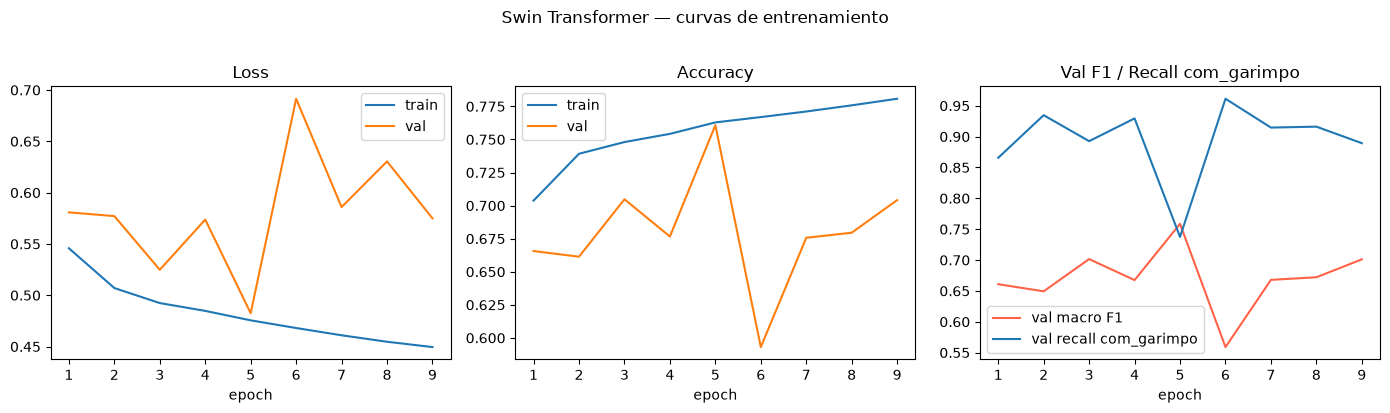

Figura guardada: C:\Users\luisg\OneDrive\Documentos\Universidad\7MO\IA\peru-illegal-mining-risk-prediction-model\reports\figures\swin_tiny_patch4_window7_224_training_curves.png


In [4]:
history = summary["history"]
epochs = [r["epoch"] for r in history["train"]]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].plot(epochs, [r["loss"] for r in history["train"]], label="train")
axes[0].plot(epochs, [r["loss"] for r in history["val"]], label="val")
axes[0].set_title("Loss"); axes[0].legend(); axes[0].set_xlabel("epoch")

axes[1].plot(epochs, [r["accuracy"] for r in history["train"]], label="train")
axes[1].plot(epochs, [r["accuracy"] for r in history["val"]], label="val")
axes[1].set_title("Accuracy"); axes[1].legend(); axes[1].set_xlabel("epoch")

axes[2].plot(epochs, [r["macro_f1"] for r in history["val"]], label="val macro F1", color="tomato")
axes[2].plot(epochs, [r["recall_com_garimpo"] for r in history["val"]], label="val recall com_garimpo")
axes[2].set_title("Val F1 / Recall com_garimpo"); axes[2].legend(); axes[2].set_xlabel("epoch")

plt.suptitle(f"{MODEL_LABEL} — curvas de entrenamiento", y=1.02)
plt.tight_layout()
fig_path = ROOT / "reports" / "figures" / f"{MODEL_NAME}_training_curves.png"
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Figura guardada: {fig_path}")

## 5. Resultado

Checkpoint en `data/06_models/swin_tiny_patch4_window7_224_best.pt`. Evalúa en test desde `05_evaluation.ipynb`.